# Fantasmas de 241 millones de años

241.000.000 de años. Esa es la edad de unas huellas que nadie buscaba donde debía.

---

**Paper:** *'Ghost' fossils of early coccolithophores point to a Triassic diversification of marine calcifying organisms*
**DOI:** [10.1038/s41467-025-65116-0](https://doi.org/10.1038/s41467-025-65116-0) — Nature Communications (2025)
**Video:** [Ver en YouTube](https://youtube.com/shorts/oCiNL0ZYmfA)

[![Abrir en Colab](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-fantasmas-cocolitoforos-triasico/notebook.ipynb)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-fantasmas-cocolitoforos-triasico/notebook.ipynb)

## El problema: esqueletos que desaparecen

Los cocolitóforos son microalgas marinas que fabrican placas de carbonato de calcio (CaCO₃) — los cocolitós. Son tan pequeños que miles caben en la cabeza de un alfiler, pero tan numerosos que, cuando mueren y se hunden, forman los acantilados blancos de Dover.

El problema es que el CaCO₃ se disuelve. Si las condiciones geológicas no son las correctas, los cocolitós desaparecen y con ellos toda evidencia de que esas microalgas existieron. Hasta ahora, el fósil más antiguo confirmado tenía ~215 millones de años.

Buscaron donde nadie había mirado: **huellas fantasma** — impresiones que los cocolitós dejaron en materia orgánica antes de disolverse. Encontraron más de 100 en rocas del Triásico Medio, en Suiza y Austria.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EDAD_MAS_ANTIGUA = 241.07    # Ma — muestra 1, Cava superiore (Suiza)
RECORD_ANTERIOR = 215        # Ma — Norian, Late Triassic
EXTENSION_MA = 26            # millones de años antes de lo que se pensaba
EXTINCION_PERMICO = 252      # Ma — la peor extinción masiva
EXTINCION_TRIASICO = 201     # Ma — segunda extinción que impulsó diversificación

COLOR_COCOLITOFOROS = '#2563EB'
COLOR_OTROS = '#BBBBBB'
COLOR_EXTENSION = '#DC2626'
COLOR_AOM = '#D97706'
COLOR_FANTASMA = '#059669'
COLOR_SIN_FANTASMA = '#94A3B8'

FUENTE = 'Fuente: Slater et al. (2025), Nature Communications | Datos: Supplementary Data 1-3'

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, urllib.request

# Estilo CaM
style_paths = ['../../cam.mplstyle', '/tmp/cam.mplstyle']
style_loaded = False
for sp in style_paths:
    if os.path.exists(sp):
        plt.style.use(sp)
        style_loaded = True
        break
if not style_loaded:
    urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-01-17-fantasmas-cocolitoforos-triasico/../../cam.mplstyle', '/tmp/cam.mplstyle')
    plt.style.use('/tmp/cam.mplstyle')

# Descargar datos si no existen (Colab)
DATA_DIR = 'datos'
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs('figuras', exist_ok=True)
    base = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-01-17-fantasmas-cocolitoforos-triasico'
    for f in ['timeline_organismos.csv', 'palinofacies.csv', 'muestras_completas.csv']:
        urllib.request.urlretrieve(f'{base}/datos/{f}', f'{DATA_DIR}/{f}')

# Cargar datos
timeline = pd.read_csv(f'{DATA_DIR}/timeline_organismos.csv')
palinofacies = pd.read_csv(f'{DATA_DIR}/palinofacies.csv')
muestras = pd.read_csv(f'{DATA_DIR}/muestras_completas.csv')

print(f"Timeline: {len(timeline)} grupos de organismos calcificadores")
print(f"Palinofacies: {len(palinofacies)} muestras ({palinofacies['examinada'].eq('Yes').sum()} examinadas)")
print(f"Muestras: {len(muestras)} rocas de Suiza y Austria")
print(f"\nMuestras con fósiles fantasma: {muestras['tiene_fantasmas'].sum()} de {len(muestras)}")

Timeline: 8 grupos de organismos calcificadores
Palinofacies: 12 muestras (8 examinadas)
Muestras: 12 rocas de Suiza y Austria

Muestras con fósiles fantasma: 5 de 12


## La línea del tiempo cambia

Veamos cuánto se mueve la historia.

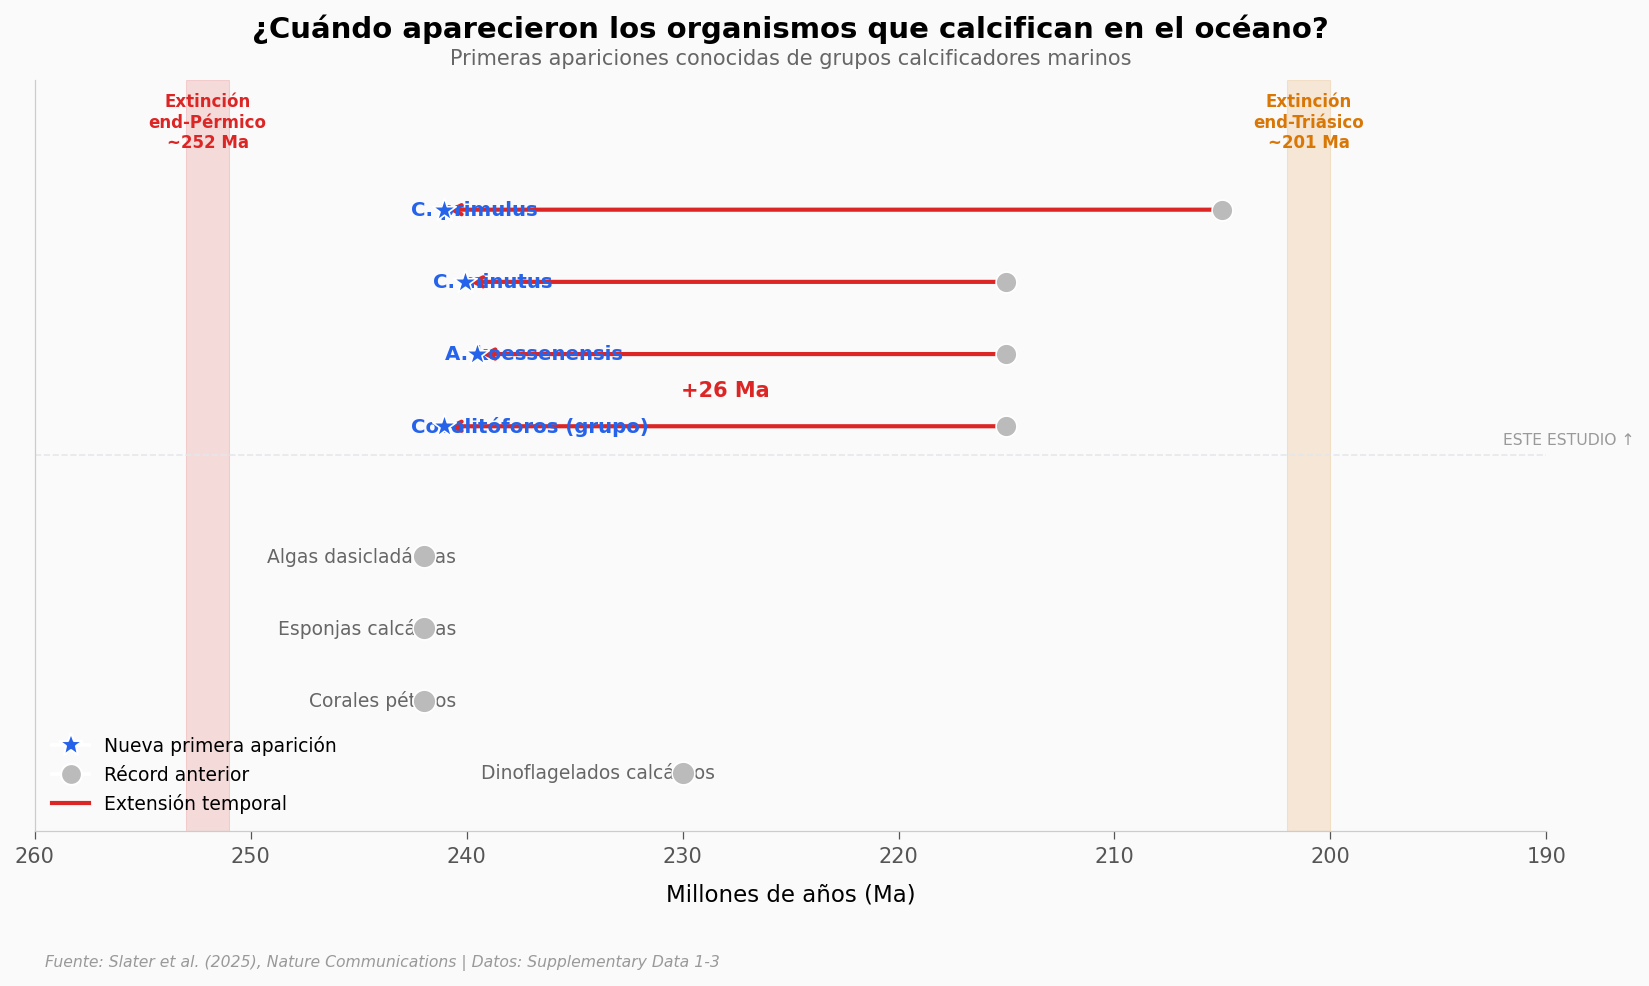

In [2]:
# ══════════════════════════════════════════════════════════════
# Gráfica hero: Timeline de organismos calcificadores marinos
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 6.5))

# Datos del timeline — orden: más recientes abajo, más antiguos arriba
# Separamos cocolitóforos (este estudio) de otros calcificadores
grupos_cocol = timeline[timeline['nueva_edad_ma'].notna()].copy()
grupos_otros = timeline[timeline['nueva_edad_ma'].isna()].copy()

# Nombres en español
nombre_es = {
    'Coccolithophores': 'Cocolitóforos (grupo)',
    'Crucirhabdus primulus': 'C. primulus',
    'Crucirhabdus minutus': 'C. minutus',
    'Archaeozygodiscus koessenensis': 'A. koessenensis',
    'Calcareous dinoflagellates': 'Dinoflagelados calcáreos',
    'Stony corals': 'Corales pétreos',
    'Calcareous sponges': 'Esponjas calcáreas',
    'Dasyclad algae': 'Algas dasicladáceas',
}

# Posiciones Y
y_positions = {}
y = 0
# Otros calcificadores primero (abajo)
for _, row in grupos_otros.iterrows():
    y_positions[row['grupo']] = y
    y += 1
y += 0.8  # Separador visual
# Cocolitóforos (arriba)
for _, row in grupos_cocol.iterrows():
    y_positions[row['grupo']] = y
    y += 1

# Dibujar bandas de extinción
ax.axvspan(251, 253, alpha=0.15, color='#DC2626', zorder=0)
ax.text(252, max(y_positions.values()) + 0.8, 'Extinción\nend-Pérmico\n~252 Ma',
        fontsize=8, color='#DC2626', ha='center', va='bottom', fontweight='bold')

ax.axvspan(200, 202, alpha=0.15, color='#D97706', zorder=0)
ax.text(201, max(y_positions.values()) + 0.8, 'Extinción\nend-Triásico\n~201 Ma',
        fontsize=8, color='#D97706', ha='center', va='bottom', fontweight='bold')

# Dibujar otros calcificadores (sin cambio)
for _, row in grupos_otros.iterrows():
    yp = y_positions[row['grupo']]
    nombre = nombre_es.get(row['grupo'], row['grupo'])
    ant = row['anterior_edad_ma']
    ax.scatter(ant, yp, color=COLOR_OTROS, s=120, zorder=5, edgecolors='white', linewidths=0.8)
    ax.text(ant - 1.5, yp, nombre, fontsize=9, color='#666666',
            ha='right', va='center')

# Dibujar cocolitóforos (con extensión)
for _, row in grupos_cocol.iterrows():
    yp = y_positions[row['grupo']]
    nombre = nombre_es.get(row['grupo'], row['grupo'])
    nueva = row['nueva_edad_ma']
    ant = row['anterior_edad_ma']

    # Flecha del récord anterior al nuevo
    ax.annotate('', xy=(nueva, yp), xytext=(ant, yp),
                arrowprops=dict(arrowstyle='->', color=COLOR_EXTENSION,
                                lw=2, connectionstyle='arc3,rad=0'))

    # Marcadores
    ax.scatter(ant, yp, color=COLOR_OTROS, s=100, zorder=5,
               edgecolors='white', linewidths=0.8, marker='o')
    ax.scatter(nueva, yp, color=COLOR_COCOLITOFOROS, s=140, zorder=6,
               edgecolors='white', linewidths=0.8, marker='*')

    # Nombre
    ax.text(nueva + 1.5, yp, nombre, fontsize=9.5, color=COLOR_COCOLITOFOROS,
            ha='left', va='center', fontweight='bold')

    # Etiqueta de extensión (solo para el grupo principal)
    if 'Coccolithophores' == row['grupo']:
        ext = nueva - ant
        ax.text((nueva + ant) / 2, yp + 0.35,
                f'+{ext:.0f} Ma', fontsize=10, color=COLOR_EXTENSION,
                ha='center', va='bottom', fontweight='bold')

# Línea separadora
sep_y = min(y_positions[g] for g in grupos_cocol['grupo']) - 0.4
ax.axhline(y=sep_y, color='#E5E7EB', linewidth=0.8, linestyle='--')
ax.text(192, sep_y + 0.15, 'ESTE ESTUDIO ↑', fontsize=7.5, color='#999999')

# Leyenda manual
legend_elements = [
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor=COLOR_COCOLITOFOROS,
               markersize=12, label='Nueva primera aparición'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_OTROS,
               markersize=10, label='Récord anterior'),
    plt.Line2D([0], [0], color=COLOR_EXTENSION, linewidth=2, label='Extensión temporal'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)

ax.set_xlim(190, 260)
ax.set_ylim(-0.8, max(y_positions.values()) + 1.8)
ax.set_xlabel('Millones de años (Ma)', fontsize=11)
ax.set_yticks([])
ax.invert_xaxis()

ax.set_title('¿Cuándo aparecieron los organismos que calcifican en el océano?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Primeras apariciones conocidas de grupos calcificadores marinos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/timeline_calcificadores.png', dpi=200, bbox_inches='tight')
plt.show()

Los cocolitóforos retroceden **26 millones de años** en el registro fósil — de ~215 Ma (Triásico Tardío) a ~241 Ma (Triásico Medio). La especie *C. primulus* salta aún más: **36 millones de años** más atrás de lo que se creía.

Lo que los datos sugieren es que los cocolitóforos no aparecieron solos. Emergen en el mismo período que corales pétreos, esponjas calcáreas y algas dasicladáceas — todos organismos que fabrican esqueletos de CaCO₃. Esa coincidencia temporal apunta a una **diversificación de calcificadores marinos** tras la extinción del Pérmico (~252 Ma), la peor que ha vivido la Tierra.

Pero hay un detalle: la diversidad de cocolitóforos se mantuvo bajísima durante ~50 millones de años, hasta que otra extinción masiva (end-Triásico, ~201 Ma) abrió el camino a su expansión.

## ¿Dónde se escondían los fantasmas?

Las huellas aparecieron en la **materia orgánica amorfa** — fragmentos lisos que resultaron ser heces de zooplancton fosilizadas. Cuando el zooplancton se comía un cocolitóforo, los cocolitós dejaban su marca en la materia fecal antes de disolverse. Exploremos qué había en cada muestra.

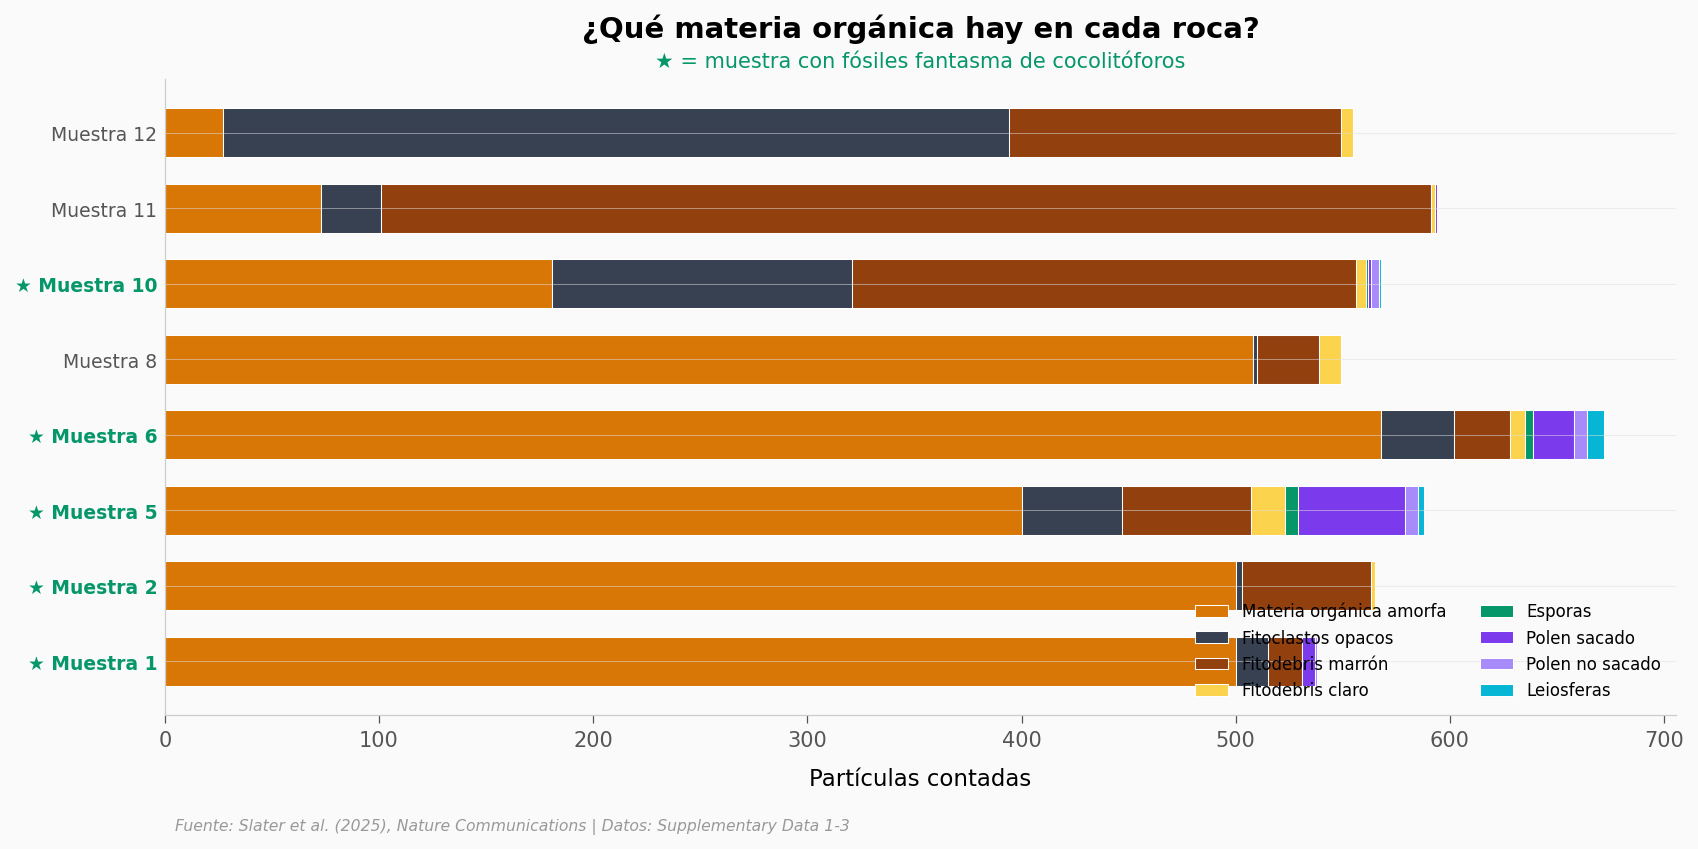

In [3]:
# ══════════════════════════════════════════════════════════════
# Composición de materia orgánica por muestra (palinofacies)
# ══════════════════════════════════════════════════════════════

pf = palinofacies[palinofacies['examinada'] == 'Yes'].copy().sort_values('muestra')

# Categorías para el stacked bar
categorias = {
    'materia_organica_amorfa': ('Materia orgánica amorfa', COLOR_AOM),
    'fitoclastos_opacos': ('Fitoclastos opacos', '#374151'),
    'fitodebris_marron': ('Fitodebris marrón', '#92400E'),
    'fitodebris_claro': ('Fitodebris claro', '#FCD34D'),
    'esporas': ('Esporas', COLOR_FANTASMA),
    'polen_sacado': ('Polen sacado', '#7C3AED'),
    'polen_no_sacado': ('Polen no sacado', '#A78BFA'),
    'leiosferas': ('Leiosferas', '#06B6D4'),
}

fig, ax = plt.subplots(figsize=(13, 5.5))

y_pos = np.arange(len(pf))
etiquetas_muestra = []

for idx, (_, row) in enumerate(pf.iterrows()):
    m = int(row['muestra'])
    ghost = row['tiene_fantasmas']
    label = f"{'★ ' if ghost else ''}Muestra {m}"
    etiquetas_muestra.append(label)

    left = 0
    for col, (nombre, color) in categorias.items():
        val = row[col] if pd.notna(row[col]) else 0
        bar = ax.barh(idx, val, left=left, color=color, height=0.65,
                      edgecolor='white', linewidth=0.5)
        left += val

# Leyenda
handles = [mpatches.Patch(facecolor=color, edgecolor='white', label=nombre)
           for _, (nombre, color) in categorias.items()]
ax.legend(handles=handles, loc='lower right', fontsize=8, framealpha=0.95, ncol=2)

ax.set_yticks(y_pos)
ax.set_yticklabels(etiquetas_muestra, fontsize=9)
# Colorear etiquetas con fantasma
for i, label in enumerate(ax.get_yticklabels()):
    m = int(pf.iloc[i]['muestra'])
    if pf.iloc[i]['tiene_fantasmas']:
        label.set_color(COLOR_FANTASMA)
        label.set_fontweight('bold')

ax.set_xlabel('Partículas contadas', fontsize=11)

ax.set_title('¿Qué materia orgánica hay en cada roca?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '★ = muestra con fósiles fantasma de cocolitóforos',
        transform=ax.transAxes, fontsize=10, color=COLOR_FANTASMA, ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/palinofacies_composicion.png', dpi=200, bbox_inches='tight')
plt.show()

Las muestras con fantasmas tienen algo en común: la materia orgánica amorfa (AOM, en ámbar) las domina. Las muestras 1, 2 y 8 tienen más del 88% de AOM — las dos primeras con fantasmas, la tercera sin ellos pese a su alta AOM (lo que sugiere que la AOM es necesaria pero no suficiente). La muestra 6 — la más productiva, con más de 70 especímenes de *C. primulus* — tiene un 84,5%.

En contraste, las muestras 11 y 12 (Austria, Norian) apenas tienen un 12,3% y 4,9% de AOM, y ninguna produjo fósiles fantasma.

¿Hay una relación entre la cantidad de AOM y la presencia de fantasmas?

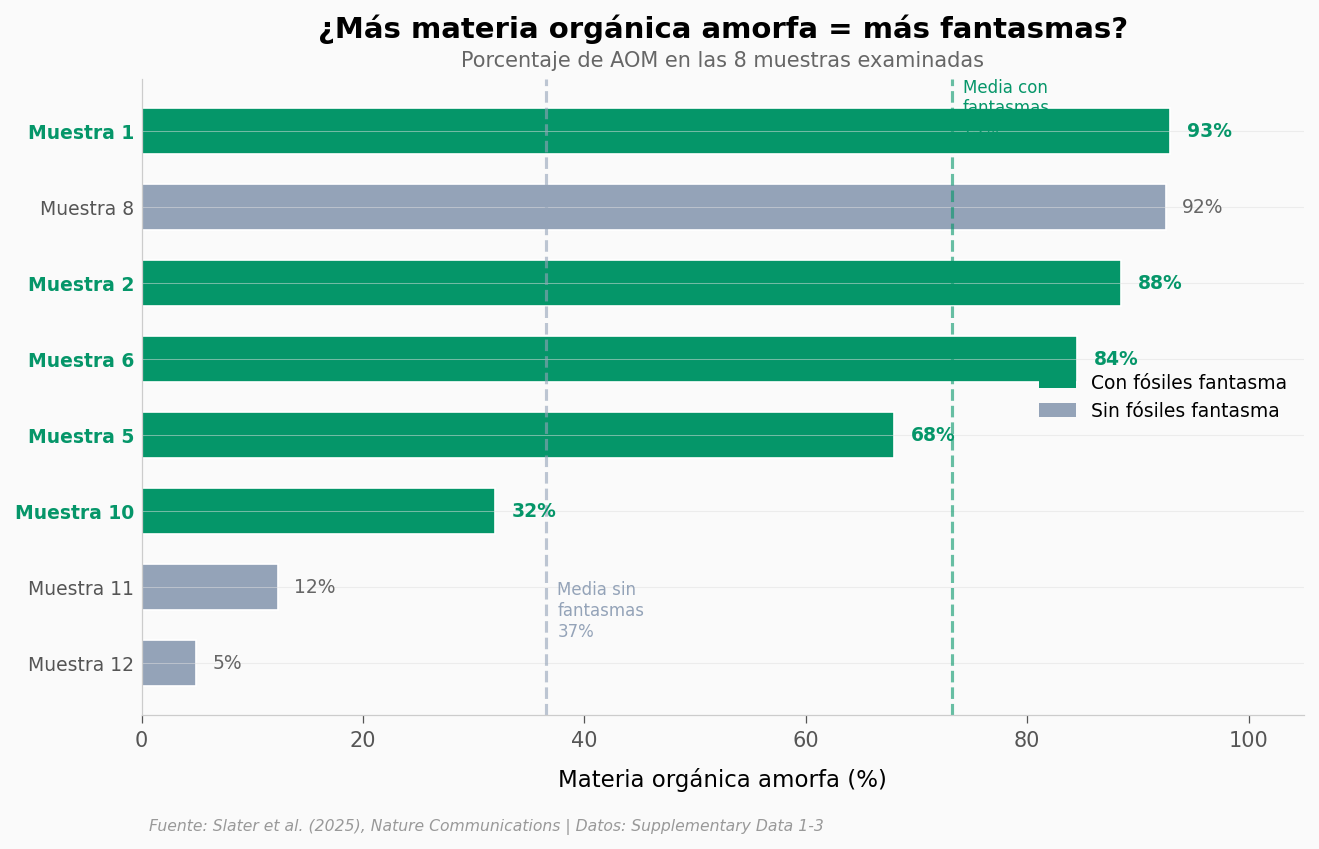

Media AOM% con fantasmas: 73.2%
Media AOM% sin fantasmas: 36.6%
Diferencia: 36.6 puntos porcentuales


In [4]:
# ══════════════════════════════════════════════════════════════
# Porcentaje de AOM: muestras con fantasmas vs sin fantasmas
# ══════════════════════════════════════════════════════════════

pf_exam = palinofacies[palinofacies['examinada'] == 'Yes'].copy()
pf_exam['pct_aom'] = (pf_exam['materia_organica_amorfa'] / pf_exam['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5.5))

# Ordenar por AOM%
pf_sorted = pf_exam.sort_values('pct_aom')
y_pos = np.arange(len(pf_sorted))

colors = [COLOR_FANTASMA if g else COLOR_SIN_FANTASMA for g in pf_sorted['tiene_fantasmas']]

bars = ax.barh(y_pos, pf_sorted['pct_aom'], color=colors, height=0.6,
               edgecolor='white', linewidth=0.8)

# Etiquetas de muestra
for i, (_, row) in enumerate(pf_sorted.iterrows()):
    m = int(row['muestra'])
    pct = row['pct_aom']
    ghost = row['tiene_fantasmas']
    ax.text(pct + 1.5, i, f"{pct:.0f}%", fontsize=9, va='center',
            fontweight='bold' if ghost else 'normal',
            color=COLOR_FANTASMA if ghost else '#666666')

etiquetas = [f"Muestra {int(row['muestra'])}" for _, row in pf_sorted.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(etiquetas, fontsize=9)
for i, (_, row) in enumerate(pf_sorted.iterrows()):
    if row['tiene_fantasmas']:
        ax.get_yticklabels()[i].set_color(COLOR_FANTASMA)
        ax.get_yticklabels()[i].set_fontweight('bold')

ax.set_xlabel('Materia orgánica amorfa (%)', fontsize=11)
ax.set_xlim(0, 105)

# Medias
media_ghost = pf_exam[pf_exam['tiene_fantasmas']]['pct_aom'].mean()
media_no = pf_exam[~pf_exam['tiene_fantasmas']]['pct_aom'].mean()
ax.axvline(x=media_ghost, color=COLOR_FANTASMA, linewidth=1.5, linestyle='--', alpha=0.6)
ax.axvline(x=media_no, color=COLOR_SIN_FANTASMA, linewidth=1.5, linestyle='--', alpha=0.6)
ax.text(media_ghost + 1, len(pf_sorted) - 0.3, f'Media con\nfantasmas\n{media_ghost:.0f}%',
        fontsize=8, color=COLOR_FANTASMA, va='top')
ax.text(media_no + 1, 0.3, f'Media sin\nfantasmas\n{media_no:.0f}%',
        fontsize=8, color=COLOR_SIN_FANTASMA, va='bottom')

# Leyenda
legend_elements = [
    mpatches.Patch(facecolor=COLOR_FANTASMA, label='Con fósiles fantasma'),
    mpatches.Patch(facecolor=COLOR_SIN_FANTASMA, label='Sin fósiles fantasma'),
]
ax.legend(handles=legend_elements, loc='center right', fontsize=9, framealpha=0.9)

ax.set_title('¿Más materia orgánica amorfa = más fantasmas?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Porcentaje de AOM en las 8 muestras examinadas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/aom_vs_fantasmas.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Media AOM% con fantasmas: {media_ghost:.1f}%")
print(f"Media AOM% sin fantasmas: {media_no:.1f}%")
print(f"Diferencia: {media_ghost - media_no:.1f} puntos porcentuales")

Las muestras con fantasmas tienen en promedio un 73% de AOM — el doble que las que no tienen (37%). No es una prueba causal (con solo 8 muestras no se puede hacer estadística formal), pero el patrón es claro: las heces fosilizadas de zooplancton fueron el vehículo de preservación.

## ¿Cuántos millones de años estuvieron escondidos?

26 millones de años. Veamos esa brecha en perspectiva.

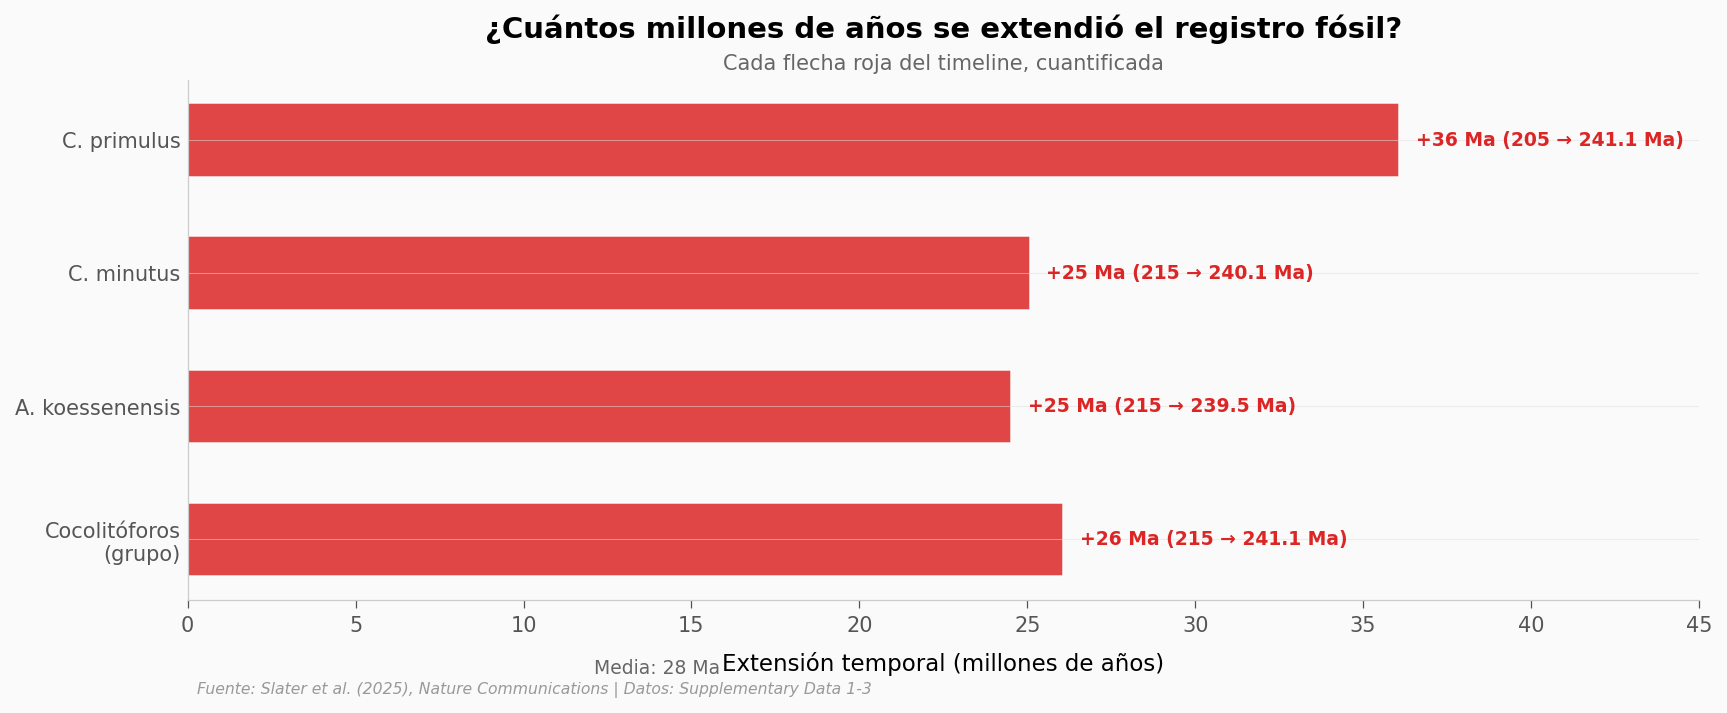

Extensión media: 27.9 Ma
Extensión máxima: C. primulus con 36.1 Ma
Extensión mínima: A. koessenensis con 24.5 Ma


In [5]:
# ══════════════════════════════════════════════════════════════
# Extensión temporal: lo que se sabía vs lo que sabemos ahora
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 4.5))

# Datos de extensión para las 4 especies/grupos con fechas nuevas
ext_data = grupos_cocol = timeline[timeline['nueva_edad_ma'].notna()].copy()
ext_data['extension_ma'] = ext_data['nueva_edad_ma'] - ext_data['anterior_edad_ma']

nombre_corto = {
    'Coccolithophores': 'Cocolitóforos\n(grupo)',
    'Crucirhabdus primulus': 'C. primulus',
    'Crucirhabdus minutus': 'C. minutus',
    'Archaeozygodiscus koessenensis': 'A. koessenensis',
}

nombres = [nombre_corto.get(g, g) for g in ext_data['grupo']]
extensiones = ext_data['extension_ma'].values

# Barras horizontales
y_pos = np.arange(len(extensiones))
bars = ax.barh(y_pos, extensiones, height=0.55, color=COLOR_EXTENSION, alpha=0.85,
               edgecolor='white', linewidth=0.8)

# Etiquetas de valor
for i, (ext, nueva, ant) in enumerate(zip(extensiones,
                                           ext_data['nueva_edad_ma'],
                                           ext_data['anterior_edad_ma'])):
    ax.text(ext + 0.5, i, f"+{ext:.0f} Ma ({ant:.0f} → {nueva:.1f} Ma)",
            fontsize=9, va='center', color=COLOR_EXTENSION, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(nombres, fontsize=10)
ax.set_xlabel('Extensión temporal (millones de años)', fontsize=11)
ax.set_xlim(0, 45)

# Flecha bidireccional de referencia
media_ext = extensiones.mean()
ax.annotate('', xy=(media_ext, -0.7), xytext=(0, -0.7),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(media_ext / 2, -0.9, f'Media: {media_ext:.0f} Ma',
        fontsize=9, color='#666666', ha='center', va='top')

ax.set_title('¿Cuántos millones de años se extendió el registro fósil?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada flecha roja del timeline, cuantificada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/extension_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Extensión media: {media_ext:.1f} Ma")
print(f"Extensión máxima: C. primulus con {extensiones.max():.1f} Ma")
print(f"Extensión mínima: A. koessenensis con {extensiones.min():.1f} Ma")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Cocolitóforos de ~241 Ma, ~26 Ma más antiguos que el récord anterior | ✅ | MOESM4: nueva edad = 241,07 Ma vs anterior ~215 Ma = 26,07 Ma. Cross-check con paper: ✅ |
| >100 fósiles fantasma preservados en heces de zooplancton | ⚠️ | Reportado en abstract. Los supplementary no detallan el conteo exacto — no podemos verificar el número preciso |
| La diversificación de calcificadores ocurrió tras la extinción end-Pérmico | ⚠️ | Los datos sugieren (T2) correlación temporal: cocolitóforos, corales y esponjas aparecen post-252 Ma. No es evidencia causal directa |
| La diversidad de cocolitóforos se mantuvo baja ~50 Ma | ⚠️ | El paper cuenta ~50 Ma desde post-Pérmico (~251 Ma) hasta post-Triásico (~201 Ma). Desde el primer fósil (~241 Ma) son ~40 Ma. Solo 3 especies en el registro disponible |
| Las muestras con más AOM tienden a tener fantasmas | ✅ | Nuestro dato: media AOM 73% con fantasmas vs 37% sin. n=8 — patrón claro, sin test estadístico formal |
| Cocolitóforos promedio 2,55 µm (n=50) | ⚠️ | Reportado en texto pero datos de medición individuales no disponibles en supplementary |

> **Limitaciones:** (1) Las edades de las muestras austriacas (Norian, ~215-218 Ma) son estimaciones por etapa geológica, no dataciones radiométricas directas. (2) Solo 8 de 12 muestras fueron examinadas para materia orgánica. (3) El conteo de >100 fantasmas no es verificable con los datos supplementary. (4) Las muestras provienen de solo 3 localidades en los Alpes — el sesgo geográfico limita la generalización.

## Ahora tú

1. **¿Qué pasa si cambias la edad del Norian?** Las muestras austriacas usan una edad estimada de ~215-218 Ma. Si el Norian medio fuera realmente ~220 Ma, ¿cuánto se reduce la extensión del récord? Prueba cambiando `RECORD_ANTERIOR` en la celda de configuración.

2. **¿Hay diferencias entre Suiza y Austria?** Filtra las muestras por país y compara la proporción de fitoclastos vs AOM. ¿Las condiciones de preservación fueron distintas?

3. **¿Y si existiera un grupo calcificador aún más antiguo?** Agrega una fila a `timeline_organismos.csv` con un organismo hipotético de 250 Ma. ¿Cómo cambia la gráfica hero?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Comparación de composición orgánica: Suiza (Ladinian) vs Austria (Norian)
# ═══════════════════════════════════════════════════════════════

pf_exam = palinofacies[palinofacies['examinada'] == 'Yes'].copy()

# Unir con datos de muestras para obtener país
pf_con_pais = pf_exam.merge(
    muestras[['muestra', 'pais', 'edad_etapa']],
    on='muestra', how='left'
)

print("Composición media por región:")
print("=" * 50)
cols_org = ['fitoclastos_opacos', 'fitodebris_marron', 'fitodebris_claro',
            'esporas', 'polen_sacado', 'polen_no_sacado', 'leiosferas',
            'materia_organica_amorfa']

for pais in ['Suiza', 'Austria']:
    subset = pf_con_pais[pf_con_pais['pais'] == pais]
    print(f"\n{pais} ({subset['edad_etapa'].iloc[0]}, n={len(subset)}):")
    total_por_muestra = subset['total'].values
    for col in cols_org:
        pct = (subset[col].fillna(0) / subset['total'] * 100).mean()
        if pct > 1:  # Solo mostrar categorías >1%
            nombre = col.replace('_', ' ').title()
            print(f"  {nombre:30} {pct:5.1f}%")

# Pregunta: ¿la dominancia de AOM en Suiza refleja mejores condiciones
# de preservación en aguas más profundas / menos oxígeno?
print("\n¿Qué explica la diferencia? El Monte San Giorgio (Suiza)")
print("era una laguna con fondo anóxico — ideal para preservar")
print("materia orgánica. Los sitios austriacos tenían más oxígeno.")

Composición media por región:

Suiza (Ladinian, n=4):
  Fitoclastos Opacos               4.1%
  Fitodebris Marron                6.9%
  Fitodebris Claro                 1.0%
  Polen Sacado                     3.1%
  Materia Organica Amorfa         83.5%

Austria (Norian, n=4):
  Fitoclastos Opacos              24.0%
  Fitodebris Marron               39.3%
  Fitodebris Claro                 1.0%
  Materia Organica Amorfa         35.4%

¿Qué explica la diferencia? El Monte San Giorgio (Suiza)
era una laguna con fondo anóxico — ideal para preservar
materia orgánica. Los sitios austriacos tenían más oxígeno.


---

### Créditos

- **Paper:** Slater et al. (2025). *'Ghost' fossils of early coccolithophores point to a Triassic diversification of marine calcifying organisms.* Nature Communications.
- **DOI:** [10.1038/s41467-025-65116-0](https://doi.org/10.1038/s41467-025-65116-0)
- **Datos:** Supplementary Data 1-3 (muestras, timeline y palinofacies), descargados de Nature Communications bajo licencia CC BY 4.0.
- **Código y notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab) | Licencia MIT